# Level 1##    








#**Task 1**#

In [ ]:
#We have import all necessary libraries:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ModuleNotFoundError: No module named 'pandas'

In [ ]:
#load the dataset:
df=pd.read_csv(r"/content/Dataset  (1).csv")
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [ ]:
#Names of row and colunms:
df.shape

(9551, 21)

##**1.1 Determine the top three most common cusines.**##



In [ ]:
cuisine_count=df['Cuisines'].str.split(',',).explode().value_counts()

top_three_cuisine=cuisine_count.head(3)
print(top_three_cuisine)


Cuisines
North Indian    2992
 Chinese        1880
 Fast Food      1314
Name: count, dtype: int64


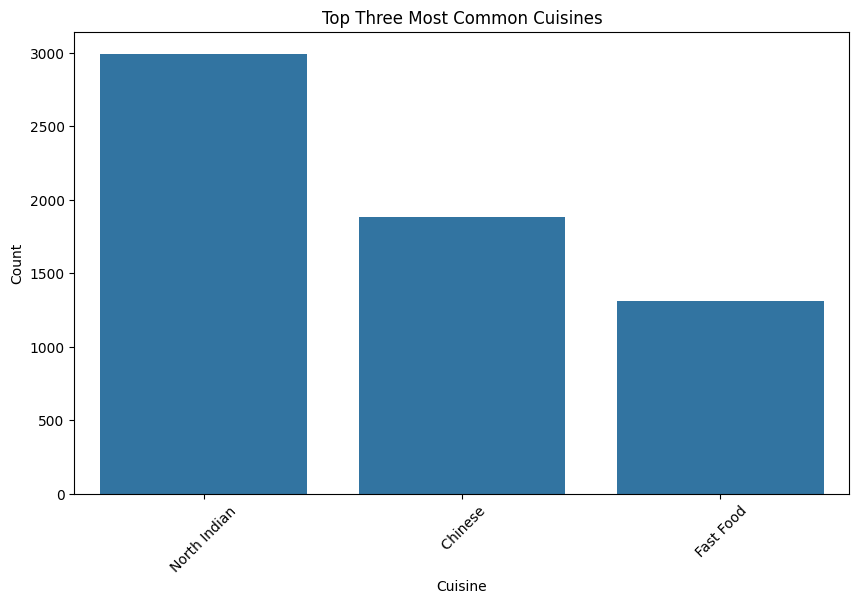

In [ ]:
top_three_cuisine=top_three_cuisine.sort_values(ascending=False)

fig,Ax=plt.subplots(figsize=(10,6))
sns.barplot(x=top_three_cuisine.index,y=top_three_cuisine.values,ax=Ax)
plt.title('Top Three Most Common Cuisines')
plt.xlabel('Cuisine')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

##1.2 Calculate the % Of Restraurants That Serve Each Of Top Cuisines ##

In [ ]:
top_restaurents=len(df)
percentage_per_cuisine=(top_three_cuisine/top_restaurents)*100
print(percentage_per_cuisine)


Cuisines
North Indian    31.326563
 Chinese        19.683803
 Fast Food      13.757722
Name: count, dtype: float64


In [ ]:
print( 'percentage of restaurants for top three cusines')
percentage_per_cuisine

percentage of restaurants for top three cusines


,count
Cuisines,
North Indian,31.326563
Chinese,19.683803
Fast Food,13.757722


Text(0.5, 1.0, 'Percentage of Restaurants Serving Top Three Cuisines')

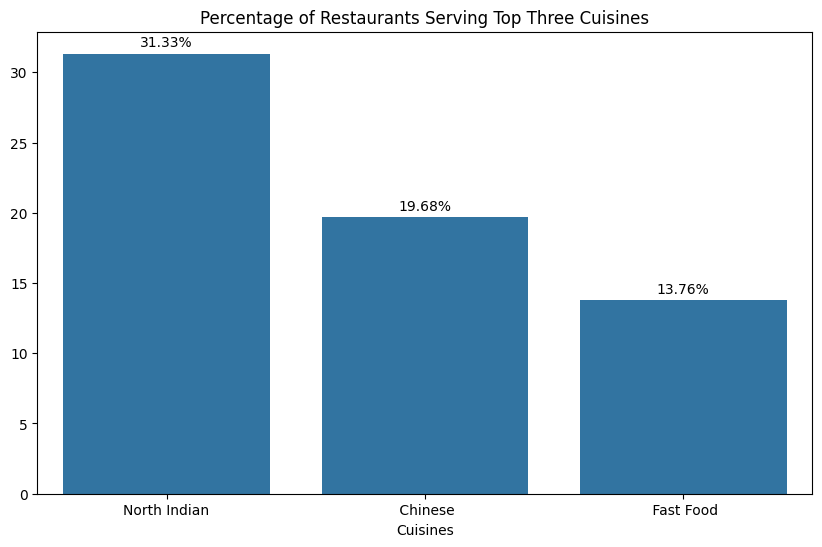

In [ ]:
fig,ax=plt.subplots(figsize=(10,6))
ab=sns.barplot(x=percentage_per_cuisine.index,y=percentage_per_cuisine.values)
for bar in ab.containers[0]:
  height=bar.get_height()
  ab.annotate(f'{height:.2f}%',xy=(bar.get_x()+bar.get_width()/2,height),xytext=(0,3),textcoords='offset points',ha='center',va='bottom')
plt.title('Percentage of Restaurants Serving Top Three Cuisines')

# **Level 1 Task 2**

#**Task: City Analysis**
-Identify the city with the highest number of restaurants in the dataset.

-Calculate the average rating for restaurants in each city.

-Determine the city with the highest


In [ ]:
#Import all necessary lirarires:


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
#load the dataset:
df=pd.read_csv(r"/content/Dataset  (1).csv")
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [ ]:
#numbers of rows and colums:
#Check Colums names and its datatype:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

**Identify the city with the highest numbers of retaurants**

In [ ]:
print(df['City'].value_counts()[[0]].index[0])

New Delhi


<ipython-input-23-f7d6f2ae9dad>:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(df['City'].value_counts()[[0]].index[0])


# **Calculate the average for restaurents in each day**

In [ ]:
#Create a Dataframe that holds the average rating for restaurents in each city:
average_restaurent_rating=df.groupby('City').agg(Average_rating=('Aggregate rating','mean')).sort_values(by='Average_rating',ascending=False)
print(average_restaurent_rating)

                  Average_rating
City                            
Inner City              4.900000
Quezon City             4.800000
Makati City             4.650000
Pasig City              4.633333
Mandaluyong City        4.625000
...                          ...
New Delhi               2.438845
Montville               2.400000
Mc Millan               2.400000
Noida                   2.036204
Faridabad               1.866932

[141 rows x 1 columns]


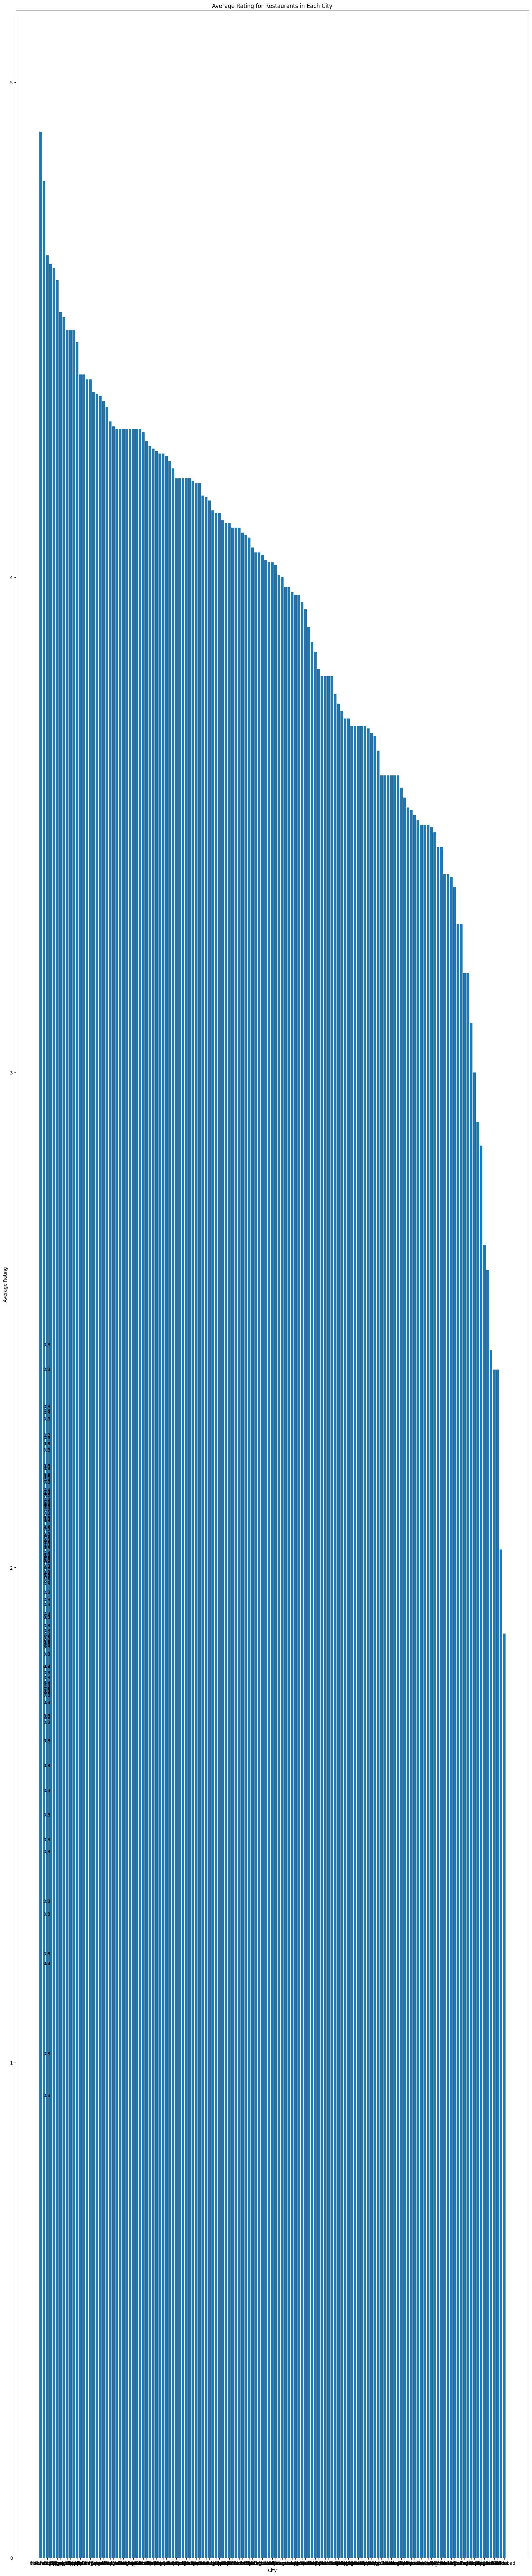

In [ ]:
plt.subplots(figsize=(20,100))
#Grouping data
average_restaurent_rating=df.groupby('City').agg(average_rating=('Aggregate rating','mean')).sort_values(by='average_rating',ascending=False)

#plotting
bars=plt.bar(average_restaurent_rating.index,average_restaurent_rating['average_rating'])

#adding labels
for bar in bars:
  plt.text(bar.get_width(),bar.get_y()+bar.get_height()/2,round(bar.get_width(),2),ha='left',va='center')

#adding title and lables
plt.title('Average Rating for Restaurants in Each City')
plt.xlabel('City')
plt.ylabel('Average Rating')

plt.show()

**The city with the highest average rating.**


In [ ]:
average_restaurent_rating=df.groupby('City').agg(average_rating=('Aggregate rating','mean')).sort_values(by='average_rating',ascending=False)
print('the city with the highest average rating is',average_restaurent_rating.index[0])

the city with the highest average rating is Inner City


#**Level 1 Tasks-3**


#Tasks: Price Range Distribution

**.Create a histogram or bar chart to
visualize the distribution of price ranges
among the restaurants.**

**.Calculate the percentage of restaurants
in each price range category.**

#Loading Dataset

In [4]:
#Import all necessary librareis:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
#load the dataset:
df=pd.read_csv(r"/content/Dataset  (1).csv")
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3.0,4.8,Dark Green,Excellent,314.0
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3.0,4.5,Dark Green,Excellent,591.0
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4.0,4.4,Green,Very Good,270.0
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4.0,4.9,Dark Green,Excellent,365.0
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4.0,4.8,Dark Green,Excellent,229.0


In [8]:
#numbers of rows and colums:
df.shape

(13423, 21)

In [9]:
#check the columns name and its datatype:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13423 entries, 0 to 13422
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         13423 non-null  int64  
 1   Restaurant Name       13423 non-null  object 
 2   Country Code          13423 non-null  int64  
 3   City                  13423 non-null  object 
 4   Address               13423 non-null  object 
 5   Locality              13423 non-null  object 
 6   Locality Verbose      13423 non-null  object 
 7   Longitude             13423 non-null  float64
 8   Latitude              13423 non-null  float64
 9   Cuisines              13413 non-null  object 
 10  Average Cost for two  13422 non-null  float64
 11  Currency              13422 non-null  object 
 12  Has Table booking     13422 non-null  object 
 13  Has Online delivery   13422 non-null  object 
 14  Is delivering now     13422 non-null  object 
 15  Switch to order men

##**Create  a histogram or bar chart  to visualize the distribution of price range among the restaurents.**

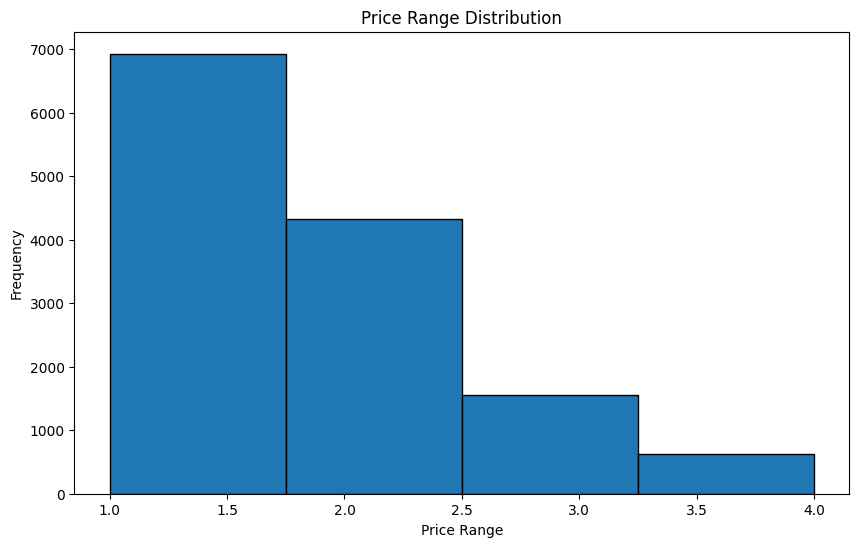

In [11]:
plt.subplots(figsize=(10,6))
plt.hist(df['Price range'],bins=df['Price range'].nunique(),edgecolor='black')
plt.title('Price Range Distribution')
plt.xlabel('Price Range')
plt.ylabel('Frequency')
plt.show()

**calculates the percentage of restaurents in each price range category.**

In [12]:
#creates a dataframe which holds the counts of restaurents by each  price range:

In [14]:
price_range_counts  =df['Price range'].value_counts().reset_index()
price_range_counts

,Price range,count
0,1.0,6926
1,2.0,4328
2,3.0,1548
3,4.0,620


In [29]:
import pandas as pd

# Assuming you have data stored in a DataFrame called 'df'

# Create a DataFrame to hold the counts of restaurants in each price range
price_range_counts = df['Price range'].value_counts().reset_index()

# Calculate the total number of restaurants
total_restaurants = len(df)

# Calculate the percentage of restaurants in each price range category
# Use the 'normalize' argument in value_counts to get percentages directly
percentage_per_price_range = df['Price range'].value_counts(normalize=True) * 100

# Print result
print("Percentage of restaurants in each price range category:")
for price_range, percentage in percentage_per_price_range.items():
    print(f"{price_range}: {percentage:.2f}%")

Percentage of restaurants in each price range category:
1.0: 51.60%
2.0: 32.25%
3.0: 11.53%
4.0: 4.62%


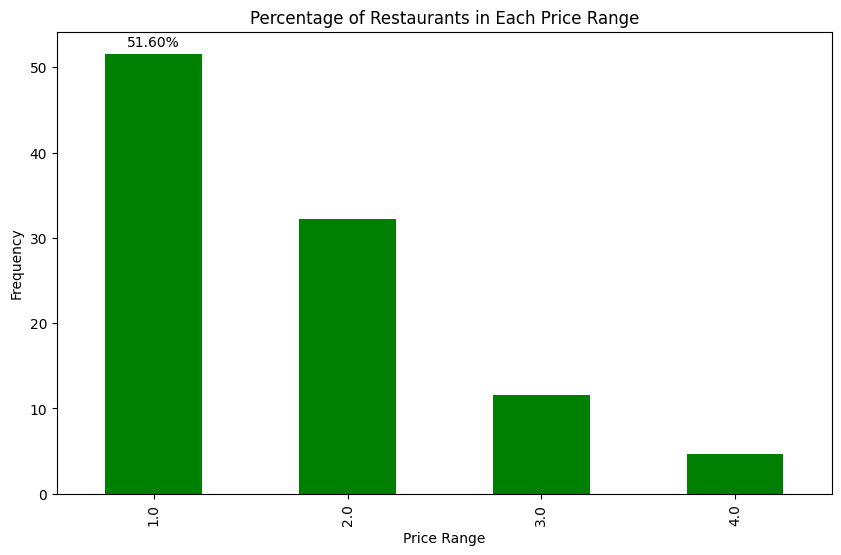

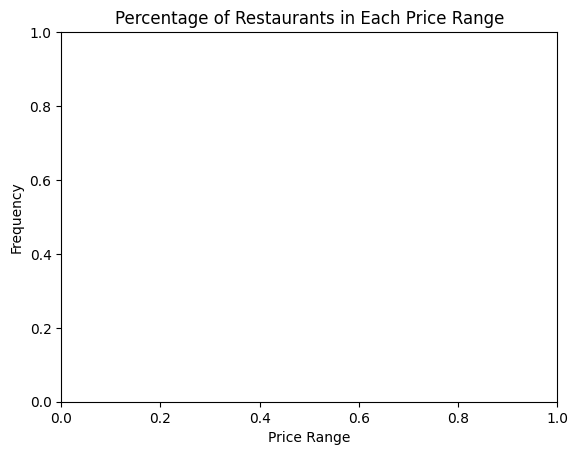

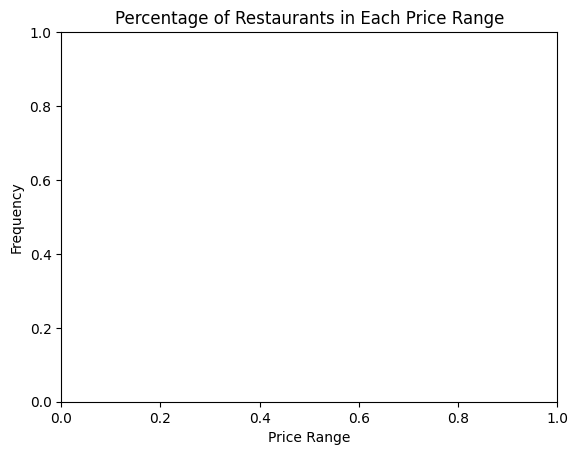

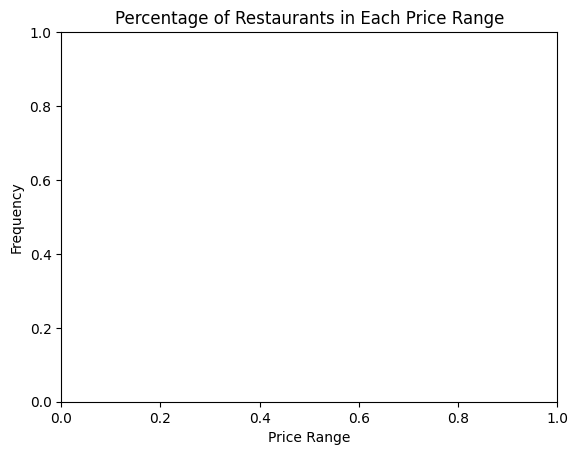

In [34]:
fig,ax=plt.subplots(figsize=(10,6))
percentage_per_price_range.plot(kind='bar',ax=ax,color='green')
for bar in ax.containers[0]:
  height=bar.get_height()
  ax.annotate(f'{height:.2f}%',xy=(bar.get_x()+bar.get_width()/2,height),xytext=(0,3),textcoords='offset points',ha='center',va='bottom')
  plt.title('Percentage of Restaurants in Each Price Range')
  plt.xlabel('Price Range')
  plt.ylabel('Frequency')
  plt.show()

# **Level 1 *Task* 4**
Task: Online Delivery

.

1.   
Determine the percentage of restaurants
that offer online delivery.

2.   
Compare the average ratings of restaurants
with and without online delivery


In [35]:
#Loading datasheet:
#import all necessary libraries:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
#load the datasheers:


In [37]:
df=pd.read_csv(r"/content/Dataset  (1).csv")
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [38]:
#numbers of rows and colums name and datatype:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14057 entries, 0 to 14056
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         14057 non-null  int64  
 1   Restaurant Name       14057 non-null  object 
 2   Country Code          14057 non-null  int64  
 3   City                  14057 non-null  object 
 4   Address               14057 non-null  object 
 5   Locality              14057 non-null  object 
 6   Locality Verbose      14057 non-null  object 
 7   Longitude             14057 non-null  float64
 8   Latitude              14057 non-null  float64
 9   Cuisines              14048 non-null  object 
 10  Average Cost for two  14057 non-null  int64  
 11  Currency              14057 non-null  object 
 12  Has Table booking     14057 non-null  object 
 13  Has Online delivery   14057 non-null  object 
 14  Is delivering now     14057 non-null  object 
 15  Switch to order men

#**Dateremine the percentage of restaurents that offer online delivery.**##

In [42]:
total_online_delivery_restaurents=len(df[df['Has Online delivery']=='Yes'])
total_restaurents=len(df)
percentage_online_delivery=(total_online_delivery_restaurents/total_restaurents)*100
print("the percentage of restaurents that offer online delivery is",percentage_online_delivery)

the percentage of restaurents that offer online delivery is 26.186241730098885


#**The average rating of restaurants with and without online delivery.**


In [61]:
#Average rating restaurants with online delivary:
restaurants_with_online_delivary=df[df['Has Online delivery']=='Yes']
average_rating_with_online_delivary=restaurants_with_online_delivary['Aggregate rating'].mean()
print('average rating of restaurants with online delivary is:',(average_rating_with_online_delivary))

average rating of restaurants with online delivary is: 3.2117359413202933


In [62]:
#Average rating restaurants without onloine delivary:
restaurants_without_online_delivary=df[df['Has Online delivery']=='No']
average_rating_without_online_delivary=restaurants_without_online_delivary['Aggregate rating'].mean()
print('average_rating_without_online_delivary:',round(average_rating_without_online_delivary,2))

average_rating_without_online_delivary: 2.3
